Using device: cuda
Loading dataset...
Label Mapping: {'NORM': 0, 'MI': 1, 'OTHER': 2, 'CD': 3, 'HYP': 4}
Dataset initialized with 21799 samples.
Validation set size: 4360
Loading trained model...
Generating predictions on the validation set...
Generating confusion matrix...


<Figure size 1000x800 with 0 Axes>

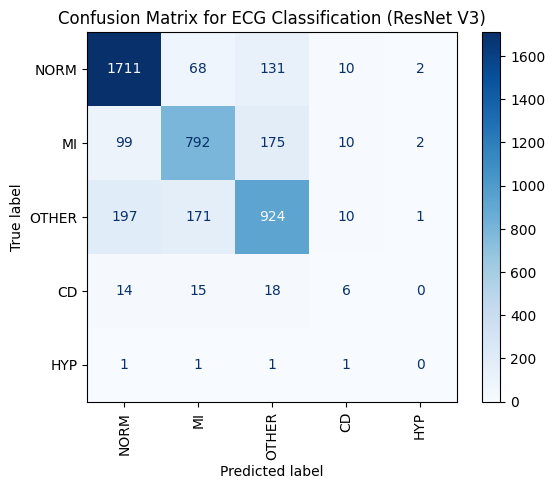

In [5]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Import our custom classes and the config file
import sys
sys.path.append('../src')
from data_loader import ECGDataset
from model_v3 import ResNet1D # <<< KEY CHANGE 1: Import the new ResNet model
import config

def evaluate_model():
    """
    Loads the trained model and evaluates its performance on the validation set,
    generating a confusion matrix.
    """
    # --- 1. Setup ---
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # --- 2. Load Data ---
    print("Loading dataset...")
    dataset = ECGDataset(data_path=config.DATA_PATH, metadata_file=config.METADATA_FILE, sampling_rate=config.SAMPLING_RATE)
    
    torch.manual_seed(42)
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    _, val_dataset = random_split(dataset, [train_size, val_size])
    
    val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False)
    print(f"Validation set size: {len(val_dataset)}")

    # --- 3. Load Model ---
    print("Loading trained model...")
    # *** KEY CHANGE 2: Initialize the new ResNet1D model ***
    model = ResNet1D(
        num_classes=config.NUM_CLASSES, 
        num_leads=config.NUM_LEADS
    ).to(device)
    
    model_path = '../models/ecg_model_v4.pth'
    try:
        model.load_state_dict(torch.load(model_path))
    except FileNotFoundError:
        print(f"Error: Model file not found at {model_path}")
        print("Please make sure you have run the training script first.")
        return
        
    model.eval()

    # --- 4. Get Predictions ---
    print("Generating predictions on the validation set...")
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for signals, labels in val_loader:
            signals, labels = signals.to(device), labels.to(device)
            
            outputs = model(signals)
            _, predicted = torch.max(outputs.data, 1)
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    # --- 5. Generate and Plot Confusion Matrix ---
    print("Generating confusion matrix...")
    cm = confusion_matrix(all_labels, all_preds)
    
    class_names = list(dataset.inverse_label_map.values())
    
    plt.figure(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
    plt.title('Confusion Matrix for ECG Classification (ResNet V3)')
    plt.show()

if __name__ == '__main__':
    evaluate_model()

In [1]:
import torch
import pandas as pd
import os
import sys

# Add the src directory to the path so we can import our custom classes
sys.path.append('../src')
from data_loader import ECGDataset
import config

# --- Step 1: Calculate Class Weights ---
# We need to load the dataset object to access its properties
print("Loading dataset to calculate weights...")
dataset = ECGDataset(data_path=config.DATA_PATH, metadata_file=config.METADATA_FILE, sampling_rate=config.SAMPLING_RATE)
df_meta = dataset.metadata # Get the processed metadata dataframe

# We will calculate weights based on the number of samples in each class
class_counts = df_meta['diagnostic_superclass'].value_counts()
total_samples = len(df_meta)

# The weight is the inverse of the class frequency, a common strategy
class_weights_dict = {class_name: total_samples / count for class_name, count in class_counts.items()}

# Now we need to create a tensor in the same order as our label_map
# The label_map is created inside the ECGDataset class
weights_tensor = torch.zeros(len(dataset.label_map))
for class_name, label_id in dataset.label_map.items():
    # Use .get(class_name, 0) to handle cases where a class might be in the map but not in the counts
    weights_tensor[label_id] = class_weights_dict.get(class_name, 0)

# We need to move these weights to the GPU for training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights_tensor = weights_tensor.to(device)

print("\n--- Calculated Class Weights ---")
print("Labels:", list(dataset.label_map.keys()))
print("Weights Tensor (for GPU):", weights_tensor)

Loading dataset to calculate weights...
Label Mapping: {'NORM': 0, 'MI': 1, 'OTHER': 2, 'CD': 3, 'HYP': 4}
Dataset initialized with 21799 samples.

--- Calculated Class Weights ---
Labels: ['NORM', 'MI', 'OTHER', 'CD', 'HYP']
Weights Tensor (for GPU): tensor([  2.2913,   4.1239,   3.2726,  69.6454, 871.9600], device='cuda:0')


In [4]:
import torch
import numpy as np

# --- Step 1: Calculate New "Dampened" Class Weights ---
# Let's start with the original weights tensor we calculated
original_weights = torch.tensor([2.2913, 4.1239, 3.2726, 69.6454, 871.9600])

# Create a copy to modify
dampened_weights = original_weights.clone()

# Dampen the weights for CD (index 3) and HYP (index 4) by taking the square root
dampened_weights[3] = torch.sqrt(original_weights[3])
dampened_weights[4] = torch.sqrt(original_weights[4])

# Move to the GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dampened_weights = dampened_weights.to(device)

print("--- Original Weights ---")
print(original_weights)
print("\n--- New Dampened Weights ---")
print(dampened_weights)

--- Original Weights ---
tensor([  2.2913,   4.1239,   3.2726,  69.6454, 871.9600])

--- New Dampened Weights ---
tensor([ 2.2913,  4.1239,  3.2726,  8.3454, 29.5290], device='cuda:0')
